# Building Baseline Classification Models with 5 Algorithms and Comparing Them Using Tabulate

# DATA MANIPUALTION, ML AND PREPROCESSING 

In [5]:
# DATA MANIPULATION
import pandas as pd
import numpy as np
import os 

# DATA VIZUALIZATION 
import matplotlib.pyplot as plt
import seaborn as sns 

# ML & PREPROCESSING 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from pathlib import Path


# DATA LOADED

In [6]:
DATA_PATH = Path('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found") 
df = pd.read_csv('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')
print(f'Loaded data: {df.shape}')

Loaded data: (10345, 17)


In [3]:
# Initial data inspection 
print('--- Dataset Shape ---')
print(df.shape)

# Display First 5 Rows 
print('\n --- First 5 Rows ---')
display(df.head())

# Data Information 
print('\n --- Data Information ---')
print(df.info())

--- Dataset Shape ---
(10345, 17)

 --- First 5 Rows ---


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56.0,Salaried,68529.50,552.0,5000.00,Electronics,12.0,13.0,1.0,0.0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19.0,Student,7247.85,300.0,1073.23,Fashion,12.0,13.0,1.0,0.0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20.0,Self-Employed,41582.26,471.0,5000.00,Electronics,3.0,19.0,2.0,0.0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21.0,Salaried,14423.46,300.0,4076.83,Sports,6.0,18.0,5.0,1.0,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43.0,Salaried,42845.50,512.0,5000.00,Electronics,9.0,0.0,0.0,0.0,7.36,India,2024-10-19,0.116698,135.2,High Risk



 --- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10343 non-null  float64
 2   employment_type       10344 non-null  str    
 3   monthly_income        10344 non-null  float64
 4   credit_score          10344 non-null  float64
 5   purchase_amount       10343 non-null  float64
 6   product_category      10341 non-null  str    
 7   bnpl_installments     10341 non-null  float64
 8   repayment_delay_days  10341 non-null  float64
 9   missed_payments       10340 non-null  float64
 10  default_flag          10342 non-null  float64
 11  app_usage_frequency   10343 non-null  float64
 12  location              10342 non-null  str    
 13  transaction_date      10343 non-null  str    
 14  debt_to_income_ratio  10343 non-null  float64
 15  ris

In [187]:
# MISSING VALUES
df.isna().sum()

user_id                 0
age                     2
employment_type         1
monthly_income          1
credit_score            1
purchase_amount         2
product_category        4
bnpl_installments       4
repayment_delay_days    4
missed_payments         5
default_flag            3
app_usage_frequency     2
location                3
transaction_date        2
debt_to_income_ratio    2
risk_score              1
customer_segment        2
dtype: int64

# HANDLING MISSING VALUES, ENCODING AND SCALING

In [4]:
class DataPreprocessing:
    def __init__(self, df):
        self.df = df
    
    # Handling Missing Values
    def miss_vals(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'str':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
        return self 
    
    # Encoding: from categorical to numercial as to translate into machine-readable language
    def encodla(self):
        le = LabelEncoder()
        cat_cols = self.df.select_dtypes(include=['str']).columns
        for col in cat_cols :
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
            self.df[col] = le.fit_transform(self.df[col])
        return self
    
    # Scaling: Transforming numerical features into a common range (like 0 to 1)
    def scaling(self):
        scaler = MinMaxScaler()
        cat_cols = self.df.select_dtypes(include=np.number).columns.drop('customer_segment')
        self.df[cat_cols] = scaler.fit_transform(self.df[cat_cols])
        return self
    
processor = DataPreprocessing(df)
df_ready = (
    processor
    .miss_vals()
    .encodla()
    .scaling()
    .df
)
print(f"Data after Preprocessing: {df_ready.shape}")
        

Data after Preprocessing: (10345, 17)


In [189]:
df_ready.isnull().sum()

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

In [190]:
df = df_ready

# MODEL SELECTION

In [191]:
# train_test_split
X = df.drop('customer_segment', axis=1)
y = df['customer_segment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LOGISTIC REGRESSION 

In [192]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# EVALUALTION MERICS OF LOGISTIC REGRESION 


In [193]:
class_report = classification_report(y_test, y_pred_lr)
con_matrix = confusion_matrix(y_test, y_pred_lr)
print("Classification report of Logistic Regression: ")
print(class_report)
print(f"Confusion Matrix of Logistic Regression: \n{con_matrix}")

Classification report of Logistic Regression: 
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1541
           1       1.00      0.84      0.91       128
           2       0.89      0.84      0.87       400

    accuracy                           0.95      2069
   macro avg       0.95      0.89      0.92      2069
weighted avg       0.95      0.95      0.95      2069

Confusion Matrix of Logistic Regression: 
[[1522    0   19]
 [   0  107   21]
 [  64    0  336]]


# DECISION TREE CLASSIFIER

In [194]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# EVALUALTION MERICS OF DECISION TREE CLASSIFIER 

In [195]:
class_report = classification_report(y_test, y_pred_dt)
con_matrix = confusion_matrix(y_test, y_pred_dt)
print("Classification report of Logistic Regression: ")
print(class_report)
print(f"Confusion Matrix of Logistic Regression: \n{con_matrix}")

Classification report of Logistic Regression: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1541
           1       1.00      1.00      1.00       128
           2       1.00      1.00      1.00       400

    accuracy                           1.00      2069
   macro avg       1.00      1.00      1.00      2069
weighted avg       1.00      1.00      1.00      2069

Confusion Matrix of Logistic Regression: 
[[1541    0    0]
 [   0  128    0]
 [   0    0  400]]


# RANDOM FOREST CLASSIFIER 

In [196]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = lr.predict(X_test)

# EVALUALTION MERICS OF RANDOM FOREST CLASSIFIER 

In [197]:
class_report = classification_report(y_test, y_pred_rf)
con_matrix = confusion_matrix(y_test, y_pred_rf)
print("Classification report of Logistic Regression: ")
print(class_report)
print(f"Confusion Matrix of Logistic Regression: \n{con_matrix}")

Classification report of Logistic Regression: 
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1541
           1       1.00      0.84      0.91       128
           2       0.89      0.84      0.87       400

    accuracy                           0.95      2069
   macro avg       0.95      0.89      0.92      2069
weighted avg       0.95      0.95      0.95      2069

Confusion Matrix of Logistic Regression: 
[[1522    0   19]
 [   0  107   21]
 [  64    0  336]]


# SUPPORT VECTOR MACHINE CLASSIFIER

In [198]:
svc = SVC(C=1.0, kernel='linear')
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# SVR CLASSIFIER EVALUATION METRICS

In [199]:
class_report = classification_report(y_test, y_pred_svc)
con_matrix = confusion_matrix(y_test, y_pred_svc)
print("Classification report of Logistic Regression: ")
print(class_report)
print(f"Confusion Matrix of Logistic Regression: \n{con_matrix}")

Classification report of Logistic Regression: 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1541
           1       0.98      0.92      0.95       128
           2       0.91      0.86      0.89       400

    accuracy                           0.96      2069
   macro avg       0.95      0.92      0.94      2069
weighted avg       0.96      0.96      0.96      2069

Confusion Matrix of Logistic Regression: 
[[1519    0   22]
 [   0  118   10]
 [  55    2  343]]


# XGBOOST CLASSIFIER

In [200]:
xgb_class = xgb.XGBClassifier(
    n_estimators = 130,
    learning_rate=0.01,
    max_depth = 5,
    subsample = 1, 
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# XGBOOST CLASSIFIER EVALUATION METRICS

In [201]:
class_report = classification_report(y_test, y_pred_xgb_class)
con_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("Classification report of Logistic Regression: ")
print(class_report)
print(f"Confusion Matrix of Logistic Regression: \n{con_matrix}")

Classification report of Logistic Regression: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1541
           1       1.00      0.99      1.00       128
           2       0.99      1.00      0.99       400

    accuracy                           1.00      2069
   macro avg       1.00      1.00      1.00      2069
weighted avg       1.00      1.00      1.00      2069

Confusion Matrix of Logistic Regression: 
[[1538    0    3]
 [   0  127    1]
 [   1    0  399]]


# TABULATE FOR DISPLAYING OF THE BEST BASELINE MODEL

In [75]:
from tabulate import tabulate

In [76]:
from tabulate import tabulate

results_baseline = [
    ['Logistic Regression', 0.95, 0.96, 0.99, 0.97],
    ['Decision Tree Classifier', 1.00, 1.00, 1.00, 1.00],
    ['Random Forest Classifier',0.95, 0.96, 0.99, 0.97],
    ['SVC',0.96, 0.97, 0.99, 0.98],
    ['XGBClassifier',1.00, 1.00, 1.00, 1.00],
    
]
headers = ['Models', 'accuracy', 'precision', 'recall', 'f1_score']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+-------------+----------+------------+
| Models                   |   accuracy |   precision |   recall |   f1_score |
+==========================+============+=============+==========+============+
| Logistic Regression      |       0.95 |        0.96 |     0.99 |       0.97 |
+--------------------------+------------+-------------+----------+------------+
| Decision Tree Classifier |       1.00 |        1.00 |     1.00 |       1.00 |
+--------------------------+------------+-------------+----------+------------+
| Random Forest Classifier |       0.95 |        0.96 |     0.99 |       0.97 |
+--------------------------+------------+-------------+----------+------------+
| SVC                      |       0.96 |        0.97 |     0.99 |       0.98 |
+--------------------------+------------+-------------+----------+------------+
| XGBClassifier            |       1.00 |        1.00 |     1.00 |       1.00 |
+--------------------------+-----------

In [77]:
best_score = max(model[1] for model in results_baseline)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_baseline:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Decision Tree Classifier', 'XGBClassifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model: {model[0]}, best accuracy is: {model[1]} which is 100%')

Best model: Decision Tree Classifier, best accuracy is: 1.0 which is 100%
Best model: XGBClassifier, best accuracy is: 1.0 which is 100%


# IMPROVEMENT PROCESS OF THE MODEL 

In [7]:
# BEFORE USING KNNIMPUTER WE NEED TO DO ENCODING PROCESS
class DataPreprocessing:
    def __init__(self, df):
        self.df = df
    
    # Handling Missing Values
    def miss_vals(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'str':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
        return self 
    
    # Encoding: from categorical to numercial as to translate into machine-readable language
    def encodla(self):
        le = LabelEncoder()
        cat_cols = self.df.select_dtypes(include=['str']).columns
        for col in cat_cols :
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
            self.df[col] = le.fit_transform(self.df[col])
        return self
    
    # Scaling: Transforming numerical features into a common range (like 0 to 1)
    def scaling(self):
        scaler = MinMaxScaler()
        cat_cols = self.df.select_dtypes(include=np.number).columns.drop('customer_segment')
        self.df[cat_cols] = scaler.fit_transform(self.df[cat_cols])
        return self
    
processor = DataPreprocessing(df)
df_ready = (
    processor
    .encodla()
    .df
)
print(f"Data after Preprocessing: {df_ready.shape}")
        

Data after Preprocessing: (10345, 17)


# HERE WE CAN SEE THE ADVANCED MISSING VALUE TREATMENT 
# KNN (SIMILARITY-BASED IMPUTATION)

In [8]:
from sklearn.impute import KNNImputer

# TARGET SEPARATE
X = df.drop("customer_segment", axis=1)
y = df["customer_segment"]

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df)
df_imputed = pd.DataFrame(df_imputed, columns=df.columns)

# IMPUTER
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

# FIT ONLY ON TRAIN
imputer.fit(X_train)

# TRANSFORM
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

In [9]:
df_imputed.isnull().sum()

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

# HERE WE CAN USE MICE (MULTIPLE IMPUTATION BY CHAINED EQUATIONS) AND PREDICTIVE(MODEL-BASED) IMPUTATION


In [208]:
# X = df.drop('customer_segment', axis=1)
# y = df['customer_segment']

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_train = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [209]:
# MICE (MULTIPLE IMPUTATION BY CHAINED EQUATIONS)[MUST BE DONE ENCODING BEFORE APPLYING FOR IT]

# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# from sklearn.ensemble import RandomForestRegressor

# imputer = IterativeImputer(estimator = RandomForestRegressor(), max_iter=10, random_state=42) # HERE WE CAN SET REGRESSOR AS WE MAY HAVE SOME CONTINOUS MISSING VALUES
# df_imputed = imputer.fit_transform(X_train) # HERE IF USE DF: IT CAUSES DATA LEAKAGE
# X_train = imputer.transform(X_train)
# X_test = imputer.transform(X_test)
# df_imputed = pd.DataFrame(df_imputed, columns=df.columns)


In [210]:
# PREDECTIVE (MODEL - BASED) IMPUTATION [MUST BE DONE ENCODING BEFORE APPLYING FOR IT]
# ALGORITHMS: RANDOM_FOREST, XGBOOST, LINEAR_REGRESSION 


# IMPLEMENTATION STRATEGY (CROSS-VALIDATION: DATA LEAKAGE PREVENTION)

In [211]:
# from sklearn.pipeline import Pipeline 
# from sklearn.model_selection import cross_val_score
# from sklearn.impute import KNNImputer 
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split

# X = df.drop('customer_segment', axis=1)
# y = df['customer_segment']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size = 0.2, random_state = 42
# )
# pipeline = Pipeline([
#     ("impute", KNNImputer(n_neighbors=5)),
#     ("model", RandomForestRegressor())
# ])

# scores = cross_val_score(pipeline, X, y, cv=5)
# print(scores)

# FEATURE ENGINEERING & SELECTION

In [10]:
df = df_imputed

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  float64
 1   age                   10345 non-null  float64
 2   employment_type       10345 non-null  float64
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  float64
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  float64
 7   bnpl_installments     10345 non-null  float64
 8   repayment_delay_days  10345 non-null  float64
 9   missed_payments       10345 non-null  float64
 10  default_flag          10345 non-null  float64
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  float64
 13  transaction_date      10345 non-null  float64
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score            10345 no

In [12]:
# TRANSFROM FEATURES

num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()

log_transformation = skewness[(skewness>=0.5)].index.tolist()
print("Log transformation columns: ", log_transformation)
print(skewness)

Log transformation columns:  ['monthly_income', 'credit_score', 'missed_payments', 'debt_to_income_ratio', 'customer_segment']
user_id                 0.000000
age                    -0.007352
employment_type         0.002564
monthly_income          0.814635
credit_score            0.799233
purchase_amount        -1.208119
product_category        0.019204
bnpl_installments       0.000758
repayment_delay_days    0.350415
missed_payments         0.970191
default_flag            0.449343
app_usage_frequency    -0.027780
location                0.015909
transaction_date        0.002363
debt_to_income_ratio    0.880176
risk_score             -0.367996
customer_segment        1.211497
dtype: float64


In [13]:
log_cols = [
    'monthly_income', 
    'credit_score', 
    'missed_payments', 
    'debt_to_income_ratio', 
    'customer_segment'
]

for col in log_cols:
    df[col + '_log'] = np.log1p(df[col])
df = df.drop(log_cols, axis=1)


In [14]:
num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
print(skewness)

user_id                     0.000000
age                        -0.007352
employment_type             0.002564
purchase_amount            -1.208119
product_category            0.019204
bnpl_installments           0.000758
repayment_delay_days        0.350415
default_flag                0.449343
app_usage_frequency        -0.027780
location                    0.015909
transaction_date            0.002363
risk_score                 -0.367996
monthly_income_log         -0.119390
credit_score_log            0.422273
missed_payments_log         0.092319
debt_to_income_ratio_log    0.693917
customer_segment_log        1.142626
dtype: float64


In [15]:
# NEGATIVE COLUMNS : SQUARED METHOD 
neg_nums = skewness[(skewness<0)].index.tolist()
print("Log transformation columns: ", neg_nums)
print(skewness)


Log transformation columns:  ['age', 'purchase_amount', 'app_usage_frequency', 'risk_score', 'monthly_income_log']
user_id                     0.000000
age                        -0.007352
employment_type             0.002564
purchase_amount            -1.208119
product_category            0.019204
bnpl_installments           0.000758
repayment_delay_days        0.350415
default_flag                0.449343
app_usage_frequency        -0.027780
location                    0.015909
transaction_date            0.002363
risk_score                 -0.367996
monthly_income_log         -0.119390
credit_score_log            0.422273
missed_payments_log         0.092319
debt_to_income_ratio_log    0.693917
customer_segment_log        1.142626
dtype: float64


In [16]:
neg_vals = [
    'age', 
    'purchase_amount', 
    'app_usage_frequency', 
    'risk_score', 
    'monthly_income_log'
]

for col in neg_vals:
    if col in df.columns:
        df[col] = df[col] ** 2

num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
print(skewness)

user_id                     0.000000
age                         0.354974
employment_type             0.002564
purchase_amount            -0.847439
product_category            0.019204
bnpl_installments           0.000758
repayment_delay_days        0.350415
default_flag                0.449343
app_usage_frequency         0.506615
location                    0.015909
transaction_date            0.002363
risk_score                  0.408263
monthly_income_log         -0.019583
credit_score_log            0.422273
missed_payments_log         0.092319
debt_to_income_ratio_log    0.693917
customer_segment_log        1.142626
dtype: float64


In [17]:
# DROP UNNECESSARY COLUMNS 
df.drop('user_id', axis=1, inplace=True)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       10345 non-null  float64
 1   employment_type           10345 non-null  float64
 2   purchase_amount           10345 non-null  float64
 3   product_category          10345 non-null  float64
 4   bnpl_installments         10345 non-null  float64
 5   repayment_delay_days      10345 non-null  float64
 6   default_flag              10345 non-null  float64
 7   app_usage_frequency       10345 non-null  float64
 8   location                  10345 non-null  float64
 9   transaction_date          10345 non-null  float64
 10  risk_score                10345 non-null  float64
 11  monthly_income_log        10345 non-null  float64
 12  credit_score_log          10345 non-null  float64
 13  missed_payments_log       10345 non-null  float64
 14  debt_to_income_ra

In [19]:
# KEEPING THE TARGET COLUMN IN ORDER TO AVOID INCLUDING WITH DROPPING FEATURES
X = df.drop('customer_segment_log', axis=1)
y = df['customer_segment_log']
# FUTURE SELECTION 
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
# REMOVE CORRELATED FEATURES
X_filtered = X.drop(columns=to_drop)
# ADD TARGET BACK
df_filtered = pd.concat([X_filtered, y], axis=1)

print("Dropped columsn: ", to_drop)
print("Original shape: ", df.shape)
print("Filtered shape: ", df_filtered.shape)

Dropped columsn:  ['credit_score_log']
Original shape:  (10345, 16)
Filtered shape:  (10345, 15)


In [20]:
# Finding high corralated features 
high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] >0.8:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correalated feature pairs (correalation > 0.8): ', corr_table)
print()

Highly correalated feature pairs (correalation > 0.8):              Feature 1         Feature 2  Correlation
0          risk_score  credit_score_log         0.85
1  monthly_income_log  credit_score_log         0.93



# CREATING A HEATMAP TO DISPLAY CORRELATIONS BETWEEN VARIABLES

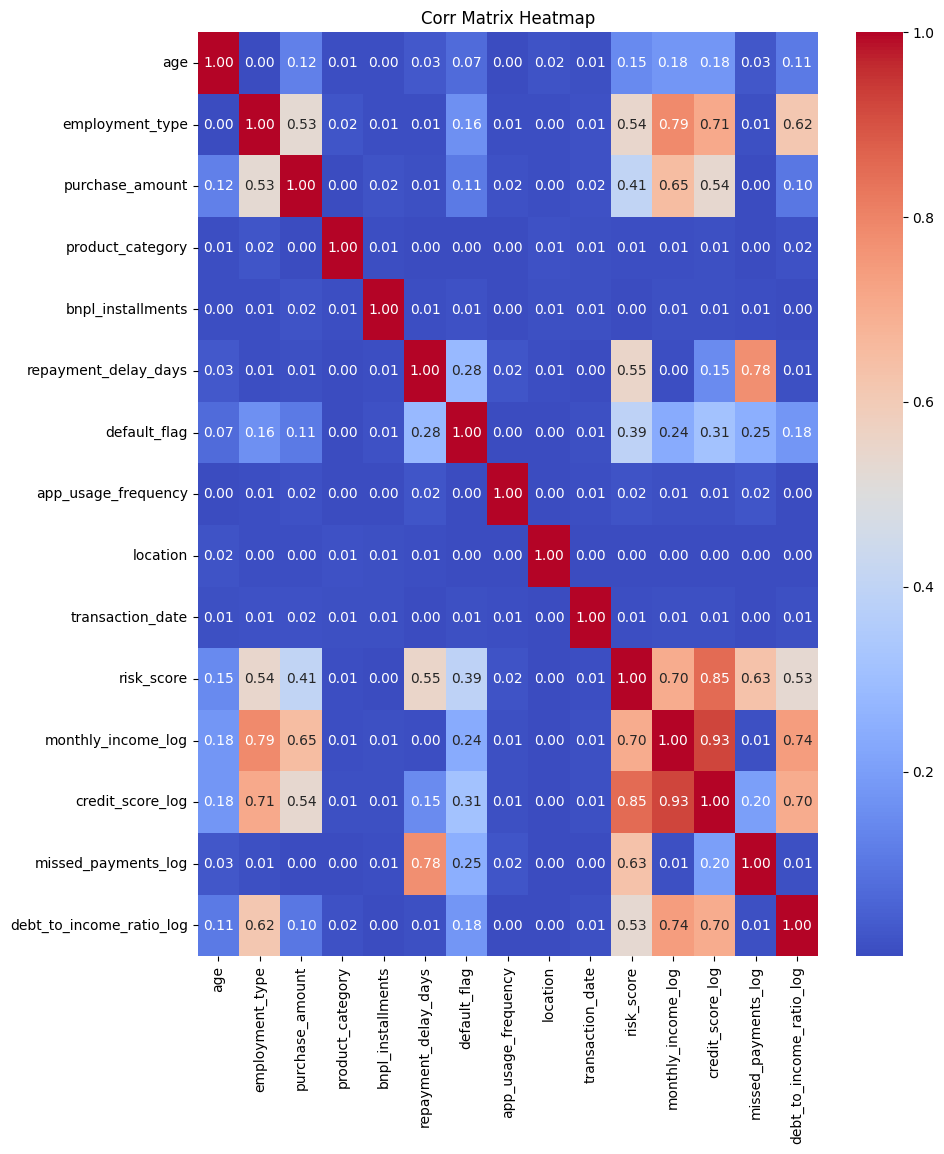

In [21]:
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
#plt.xticks(rotation=45) #rotate x -axis for 45 degree
plt.title('Corr Matrix Heatmap')
plt.show()

In [22]:
# FINDING LOW VARIANCES
from sklearn.feature_selection import VarianceThreshold

X = df_filtered.drop('customer_segment_log', axis=1)
y = df_filtered['customer_segment_log']

threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
selector.fit(X)

# LOW VARIANCE COLUMNS
low_variance_features = X.columns[~selector.get_support()]
print("Low variance features to drop: ")
print(list(low_variance_features))

# DROP THE LOW VARIANCE COLUMNS 
X_filtered = X.drop(columns= low_variance_features)

# ADD TARGET BACK
df_final = pd.concat([X_filtered, y], axis=1)

print("Original shape: ", df_filtered.shape)
print("New filtered shape: ", df_final.shape)


Low variance features to drop: 
[]
Original shape:  (10345, 15)
New filtered shape:  (10345, 15)


In [23]:
df = df_final

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       10345 non-null  float64
 1   employment_type           10345 non-null  float64
 2   purchase_amount           10345 non-null  float64
 3   product_category          10345 non-null  float64
 4   bnpl_installments         10345 non-null  float64
 5   repayment_delay_days      10345 non-null  float64
 6   default_flag              10345 non-null  float64
 7   app_usage_frequency       10345 non-null  float64
 8   location                  10345 non-null  float64
 9   transaction_date          10345 non-null  float64
 10  risk_score                10345 non-null  float64
 11  monthly_income_log        10345 non-null  float64
 12  missed_payments_log       10345 non-null  float64
 13  debt_to_income_ratio_log  10345 non-null  float64
 14  customer_segment_

In [25]:
# SCALING (NORMALIZATION)

class DataPreprocessing:
    def __init__(self, df):
        self.df = df
    
    # Handling Missing Values
    def miss_vals(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'str':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
        return self 
    
    # Encoding: from categorical to numercial as to translate into machine-readable language
    def encodla(self):
        le = LabelEncoder()
        cat_cols = self.df.select_dtypes(include=['str']).columns
        for col in cat_cols :
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
            self.df[col] = le.fit_transform(self.df[col])
        return self
    
    # Scaling: Transforming numerical features into a common range (like 0 to 1)
    def scaling(self):
        scaler = MinMaxScaler()
        cat_cols = self.df.select_dtypes(include=np.number).columns.drop('customer_segment_log')
        self.df[cat_cols] = scaler.fit_transform(self.df[cat_cols])
        return self
    
processor = DataPreprocessing(df)
df_ready = (
    processor
    .scaling()
    .df
)
print(f"Data after Preprocessing: {df_ready.shape}")
        

Data after Preprocessing: (10345, 15)


In [228]:
df = df_ready

In [26]:
df.head()

,age,employment_type,purchase_amount,product_category,bnpl_installments,repayment_delay_days,default_flag,app_usage_frequency,location,transaction_date,risk_score,monthly_income_log,missed_payments_log,debt_to_income_ratio_log,customer_segment_log
0,0.890719,0.000000,1.000000,0.25,1.000000,0.393939,0.0,0.717981,0.0,0.439560,0.172288,0.747493,0.333333,0.128074,1.098612
1,0.011720,0.666667,0.045691,0.50,1.000000,0.393939,0.0,0.086344,1.0,0.766484,0.446681,0.093884,0.333333,0.252567,0.000000
2,0.024073,0.333333,1.000000,0.25,0.000000,0.575758,0.0,0.101908,0.0,0.258242,0.332796,0.589457,0.528321,0.207416,0.000000
3,0.037061,0.000000,0.664688,1.00,0.333333,0.545455,1.0,0.336764,0.4,0.478022,0.800081,0.278504,0.861654,0.456502,0.000000
4,0.483054,0.000000,1.000000,0.25,0.666667,0.000000,0.0,0.537067,0.6,0.799451,0.115395,0.598720,0.000000,0.201584,0.000000


# MODEL SELECTION AFTER FEATURE ENGINEERING AND SELECTION PROCESS

In [29]:
# train_test_split
X = df.drop('customer_segment_log', axis=1)
y = df['customer_segment_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# LOGISTIC REGRESSION AFTER FE AND FS

In [30]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# THRESHOLD TUNNING AND ADVANCED METRICS OF LOGISTIC REGRESSION

In [31]:
probs = lr.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.95311643 0.04688357]
Model confidence for positive class: 4.76%


In [33]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.5716723549488054
Recall:  0.8375

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.6565096952908587
Recall:  0.5925

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0


# DECISION TREE CLASSIFIER AFTER FE AND FS

In [34]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# THRESHOLD TUNNING AND ADVANCED METRICS OF DECISION TREE CLASSIFIER

In [36]:
probs = dt.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [1. 0.]
Model confidence for positive class: 0.00%


In [37]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.8866498740554156
Recall:  0.88

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.8866498740554156
Recall:  0.88

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.8866498740554156
Recall:  0.88


# RANDOM FOREST CLASSIFIER AFTER FE AND FS

In [41]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# THRESHOLD TUNNING AND ADVANCED METRICS OF RANDOM FOREST CLASSIFIER

In [42]:
probs = rf.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.99 0.01]
Model confidence for positive class: 6.00%


In [43]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.8434782608695652
Recall:  0.97

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.9246753246753247
Recall:  0.89

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.9817518248175182
Recall:  0.6725


# SUPPORT VECTOR MACHINE CLASSIFIER AFTER FE AND FS

In [49]:
svc = SVC(kernel='rbf', C=1.0, probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# THRESHOLD TUNNING AND ADVANCED METRICS OF SVR 

In [50]:
probs = svc.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.98029456 0.01970544]
Model confidence for positive class: 7.13%


In [51]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.6281800391389433
Recall:  0.8025

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.6793893129770993
Recall:  0.6675

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.4563106796116505
Recall:  0.1175


# XGBOOST CLASSIFIER AFTER FE AND FS

In [55]:
xgb_class = xgb.XGBClassifier(
    n_estimators = 100,
    learning_rate=0.1,
    max_depth = 3,
    subsample = 1, 
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# THRESHOLD TUNNING AND ADVANCED METRICS OF XGBOOST CLASSIFIER

In [56]:
probs = xgb_class.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.99628794 0.00371206]
Model confidence for positive class: 0.42%


In [57]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.8278867102396514
Recall:  0.95

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.8975
Recall:  0.8975

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.9663299663299664
Recall:  0.7175


# ALL EVALUATION METRICS AFTER THRESHOLD TUNNING

In [59]:
# LOGISTIC REGRESSION 
class_report = classification_report(y_test, y_pred_lr)
con_matrix = confusion_matrix(y_test, y_pred_lr)
print("Classification report of Logistic Regression: ")
print(class_report)
print(f"Confusion Matrix of Logistic Regression: \n{con_matrix}")

Classification report of Logistic Regression: 
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1669
           1       0.66      0.59      0.62       400

    accuracy                           0.86      2069
   macro avg       0.78      0.76      0.77      2069
weighted avg       0.86      0.86      0.86      2069

Confusion Matrix of Logistic Regression: 
[[1545  124]
 [ 163  237]]


In [65]:
# DECISION TREE CLASSIFIER 
class_report = classification_report(y_test, y_pred_dt)
con_matrix = confusion_matrix(y_test, y_pred_dt)
print("Classification report of Decision Tree Classifier: ")
print(class_report)
print(f"Confusion Matrix of Decision Tree Classifier: \n{con_matrix}")

Classification report of Decision Tree Classifier: 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1669
           1       0.89      0.88      0.88       400

    accuracy                           0.96      2069
   macro avg       0.93      0.93      0.93      2069
weighted avg       0.95      0.96      0.95      2069

Confusion Matrix of Decision Tree Classifier: 
[[1624   45]
 [  48  352]]


In [66]:
# RANDOM FOREST CLASSIFIER
class_report = classification_report(y_test, y_pred_rf)
con_matrix = confusion_matrix(y_test, y_pred_rf)
print("Classification report of Random Forest Classifier: ")
print(class_report)
print(f"Confusion Matrix of Random Forest Classifier: \n{con_matrix}")

Classification report of Random Forest Classifier: 
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1669
           1       0.92      0.88      0.90       400

    accuracy                           0.96      2069
   macro avg       0.95      0.93      0.94      2069
weighted avg       0.96      0.96      0.96      2069

Confusion Matrix of Random Forest Classifier: 
[[1640   29]
 [  50  350]]


In [67]:
# SVC
class_report = classification_report(y_test, y_pred_svc)
con_matrix = confusion_matrix(y_test, y_pred_svc)
print("Classification report of SVC: ")
print(class_report)
print(f"Confusion Matrix of SVC: \n{con_matrix}")

Classification report of SVC: 
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      1669
           1       0.65      0.77      0.71       400

    accuracy                           0.88      2069
   macro avg       0.80      0.84      0.81      2069
weighted avg       0.89      0.88      0.88      2069

Confusion Matrix of SVC: 
[[1503  166]
 [  91  309]]


In [68]:
# XGBOOST CLASSIFIER 
class_report = classification_report(y_test, y_pred_xgb_class)
con_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("Classification report of XGBoost Classifier: ")
print(class_report)
print(f"Confusion Matrix of XGBoost Classifier: \n{con_matrix}")

Classification report of XGBoost Classifier: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1669
           1       0.90      0.90      0.90       400

    accuracy                           0.96      2069
   macro avg       0.94      0.94      0.94      2069
weighted avg       0.96      0.96      0.96      2069

Confusion Matrix of XGBoost Classifier: 
[[1628   41]
 [  41  359]]


In [69]:
from tabulate import tabulate

results_improvement = [
    ['Logistic Regression', 0.86, 0.90, 0.93, 0.92],
    ['Decision Tree Classifier', 0.96, 0.97,0.97,0.97],
    ['Random Forest Classifier',0.96, 0.97 ,0.98, 0.98],
    ['SVC',0.88, 0.94, 0.90, 0.92],
    ['XGBClassifier',0.96, 0.98, 0.98, 0.98]
    
]
headers = ['Models', 'accuracy', 'precision', 'recall', 'f1_score']
table = tabulate(results_improvement, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+-------------+----------+------------+
| Models                   |   accuracy |   precision |   recall |   f1_score |
+==========================+============+=============+==========+============+
| Logistic Regression      |       0.86 |        0.90 |     0.93 |       0.92 |
+--------------------------+------------+-------------+----------+------------+
| Decision Tree Classifier |       0.96 |        0.97 |     0.97 |       0.97 |
+--------------------------+------------+-------------+----------+------------+
| Random Forest Classifier |       0.96 |        0.97 |     0.98 |       0.98 |
+--------------------------+------------+-------------+----------+------------+
| SVC                      |       0.88 |        0.94 |     0.90 |       0.92 |
+--------------------------+------------+-------------+----------+------------+
| XGBClassifier            |       0.96 |        0.98 |     0.98 |       0.98 |
+--------------------------+-----------

In [73]:
best_score = max(model[1] for model in results_improvement)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_improvement:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Decision Tree Classifier', 'Random Forest Classifier','XGBClassifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model after FE and FS: {model[0]}, best accuracy is: {model[1]} which is 96%')

Best model after FE and FS: Decision Tree Classifier, best accuracy is: 0.96 which is 96%
Best model after FE and FS: Random Forest Classifier, best accuracy is: 0.96 which is 96%
Best model after FE and FS: XGBClassifier, best accuracy is: 0.96 which is 96%


In [79]:
best_score = max(model[1] for model in results_baseline)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_baseline:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Decision Tree Classifier', 'XGBClassifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model for baseline: {model[0]}, best accuracy is: {model[1]} which is 100%')

Best model for baseline: Decision Tree Classifier, best accuracy is: 1.0 which is 100%
Best model for baseline: XGBClassifier, best accuracy is: 1.0 which is 100%


In [80]:
"""
IN THE BASELINE MODEL, THE CLASSIFIER WAS EVALUATED USING THREE TARGET CLASSES (0, 1, AND 2). 
HOWEVER, AFTER APPLYING FEATURE ENGINEERING (FE) AND FEATURE SELECTION (FS), 
THE TARGET VARIABLE UNEXPECTEDLY CHANGED INTO ONLY TWO CLASSES (0 AND 1).
THE EXACT REASON FOR THIS CHANGE IS STILL UNCLEAR AND REQUIRES FURTHER INVESTIGATION.

ADDITIONALLY, THE BASELINE MODEL ACHIEVED 100% ACCURACY, 
WHICH STRONGLY SUGGESTS THE POSSIBILITY OF OVERFITTING. 
THIS MAY INDICATE THAT THE MODEL MEMORIZED THE TRAINING DATA INSTEAD OF LEARNING GENERALIZABLE PATTERNS. 
AFTER APPLYING THE IMPROVEMENT TECHNIQUES, THE MODEL ACCURACY DECREASED TO 96%, 
WHICH IS STILL A STRONG PERFORMANCE BUT LIKELY REFLECTS BETTER GENERALIZATION 
AND A MORE REALISTIC EVALUATION OF THE MODEL'S PREDICTIVE CAPABILITY.

"""

"\nIN THE BASELINE MODEL, THE CLASSIFIER WAS EVALUATED USING THREE TARGET CLASSES (0, 1, AND 2). \nHOWEVER, AFTER APPLYING FEATURE ENGINEERING (FE) AND FEATURE SELECTION (FS), \nTHE TARGET VARIABLE UNEXPECTEDLY CHANGED INTO ONLY TWO CLASSES (0 AND 1).\nTHE EXACT REASON FOR THIS CHANGE IS STILL UNCLEAR AND REQUIRES FURTHER INVESTIGATION.\n\nADDITIONALLY, THE BASELINE MODEL ACHIEVED 100% ACCURACY, \nWHICH STRONGLY SUGGESTS THE POSSIBILITY OF OVERFITTING. \nTHIS MAY INDICATE THAT THE MODEL MEMORIZED THE TRAINING DATA INSTEAD OF LEARNING GENERALIZABLE PATTERNS. \nAFTER APPLYING THE IMPROVEMENT TECHNIQUES, THE MODEL ACCURACY DECREASED TO 96%, \nWHICH IS STILL A STRONG PERFORMANCE BUT LIKELY REFLECTS BETTER GENERALIZATION \nAND A MORE REALISTIC EVALUATION OF THE MODEL'S PREDICTIVE CAPABILITY.\n\n"

# BEST MODEL USING JOBLIB FOR FUTURE USE

In [88]:
from joblib import dump, load
dump(results_improvement, 'best_models.joblib')

['best_models.joblib']